In [1]:
import warnings

warnings.simplefilter("ignore")
#from altaipony.lcio import from_mast
#from funcs.detrend import custom_detrending, estimate_detrended_noise
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

In [2]:
search_result = search_lightcurve("AU Mic") 
lc2min = search_result[3].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
#lc2_m = lc2.remove_nans()
lc2_m = lc2.normalize().remove_nans()

In [3]:
x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

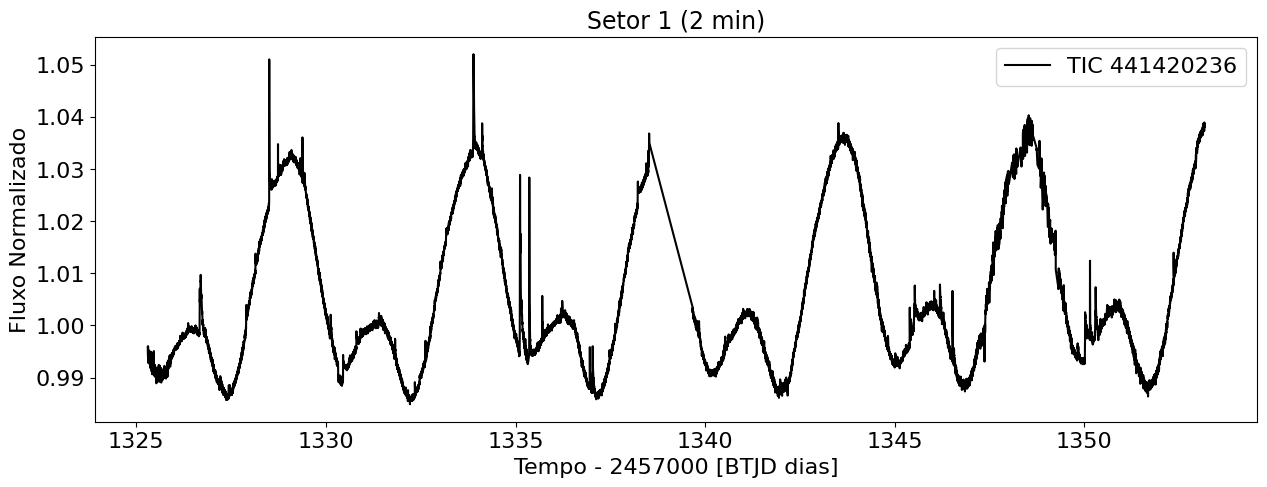

In [4]:
#%matplotlib notebook
plt.rcParams['font.size'] = '16' 
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x2min,y2min,'k')
labels= ["TIC 441420236"]
ax.set_xlabel('Tempo - 2457000 [BTJD dias]').set_fontsize(16)
ax.set_ylabel('Fluxo Normalizado').set_fontsize(16)  
plt.title('Setor 1 (2 min)').set_fontsize(17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend(labels) 
plt.show()

In [5]:
########### FLATTEN NOVO ##################

vetores = [
    [1326.6711, 1326.7794],
    [1327.8929, 1327.9763],
    [1328.4985, 1328.5822],
    [1328.4130, 1328,690],
    [1328.7326, 1328.7474],
    [1329.3756, 1329.4123],
    [1330.1210, 1330.1377],
    [1330.4496, 1330.5464],
    [1331.8210, 1331.8574],
    [1333.8797, 1333.9809],
    [1334.1134, 1334.1507],
    [1335.1052, 1335.2524],
    [1335.3517, 1335.4232],
    [1335.7022, 1335.7252],
    [1336.2287, 1336.2454],
    [1336.9519, 1336.9890],
    [1337.0179, 1337.0633],
    [1338.2201, 1338.2396],
    [1338.4973, 1338.5127],
    [1343.5045, 1343.5218],
    [1345.3914, 1345.4122],
    [1345.3918, 1345.4119],
    [1345.5044, 1345.5562],
    [1346.1841, 1346.2377],
    [1346.5162, 1346.5464],
    [1350.0068, 1350.0502],
    [1350.1441, 1350.3345],
    [1350.2795, 1350.3247],
    [1330.3039, 1330.4724],
    [1347.3173, 1347.3250],
    [1342.2240, 1342.2398],
    [1352.3514, 1352.3619],
    [1349.4516, 1349.4714],
    [1349.8142, 1349.8432],
    [1345.3926, 1345.4123],
    [1350.2720, 1350.3608],
    [1350.0112, 1350.4109],
    [1349.2727, 1349.3229],
]

vetor_true = [False]*len(x2min)


#indices = []
#indices = np.where((x2min>=vetores[0][0]) & (x2min<=vetores[0][1]))

for j in range(len(x2min)):
    for i in range(len(vetores)):
        if (x2min[j]>=vetores[i][0]) and (x2min[j]<=vetores[i][1]):
            vetor_true[j] = True

mascara = np.array(vetor_true)



flcd = lc2_m.flatten(window_length=300, polyorder=4, return_trend=True, break_tolerance=100, niters=3, sigma=2.5, mask=mascara)
x_detrend = np.ascontiguousarray(flcd[1].time.value, dtype=np.float64) 
y_detrend = np.ascontiguousarray(flcd[1].flux, dtype=np.float64)
yerr_detrend= np.ascontiguousarray(flcd[1].flux_err, dtype=np.float64)

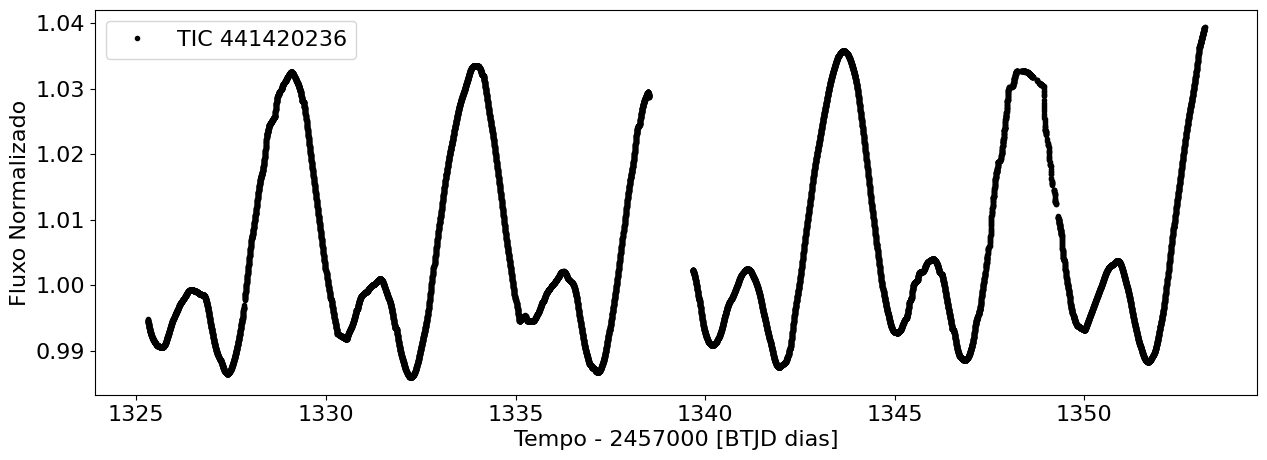

In [6]:


fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x_detrend,y_detrend,'k.',label = 'TIC 441420236',)
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()

In [16]:
flcd.to_fits(path='lightcurve_s3.fits', overwrite=True)


AttributeError: 'tuple' object has no attribute 'to_fits'

In [9]:
#Transformando os arquivos em fits e salvando 
from astropy.io import fits
hdu = fits.open('lightcurve2.fits')
type(hdu)

FileNotFoundError: [Errno 2] No such file or directory: 'lightcurve2.fits'

In [11]:
from astropy.table import Table
dat = Table.read('lightcurve2.fits', format='fits')
df = dat.to_pandas()

FileNotFoundError: [Errno 2] No such file or directory: 'lightcurve2.fits'

In [12]:
print(df.isna().sum()) #Contagem de dados nans nas colunas
df = df.dropna(subset=['TIME']) 
df = df.dropna(subset=['QUALITY']) # retirar valores 
print(df.isna().sum())
df.drop(df[df.QUALITY>0].index ,inplace=True) # exclui linhas onde flag com raios cósmicos

NameError: name 'df' is not defined

In [ ]:
%matplotlib inline
time=df["TIME"] # tempo
flux=df["FLUX"] #flux
s=df["QUALITY"] # sap_quality
sf  = df['QUALITY'] > 1 # filtra flag com valores maiores que 1 ou seja flag 128 e 8192, são raios cósmicos
#from scipy.signal import savgol_filter
rf = np.mean(flux)/np.mean(flux) #Fluxo relativo

In [ ]:

fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(time,flux, 'k*-')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()

In [ ]:
#%matplotlib notebook
#Calculando a média simples dos dados 
y_mean = [np.median(flux)]*len(time)

fig,ax = plt.subplots(1,1,figsize=(15,5))

data_line = ax.plot(time,flux, label='Dados', marker='.', color='black')

mean_line = ax.plot(time,y_mean+np.array(np.std(flux)), label='Média+$\sigma$', linestyle='--', color = 'red')
#mean_line = ax.plot(time,y_mean+np.std(flux), label='Mean+std', linestyle='--', color = 'red')

#Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()
plt.show()


In [ ]:
#%matplotlib notebook
#Calculando a média simples dos dados 
y_mean = [np.median(flux)]*len(time)

fig,ax = plt.subplots(1,1,figsize=(15,5))

data_line = ax.plot(time,flux, label='Dados', marker='.', color='black')

mean_line = ax.plot(time,y_mean+np.array(np.std(flux)), label='Média+$\sigma$', linestyle='--', color = 'red')
#mean_line = ax.plot(time,y_mean+np.std(flux), label='Mean+std', linestyle='--', color = 'red')

#Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Valores de início e término da flare (substitua pelos valores desejados)
start_input = 1327.8932
stop_input = 1326.8041

def ener_flare(start, stop, time, flux):
    flux_flare = []
    tempo_flare = []
    for i in range(len(time)):
        if time[i] >= start and time[i] <= stop:
            flux_flare.append(flux[i])
            tempo_flare.append(time[i])

    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    
    return flux_flare, tempo_flare

# Chamada da função ener_flare com os dados de exemplo
flux_flare, tempo_flare = ener_flare(start_input, stop_input, time, flux)
# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare, flux_flare, 'r')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

In [20]:

#fl129=pd.read_csv('paola_flares1.csv') #lendo os flares 
tess_f = pd.read_csv('tess_functionx1.csv') #lendo os arquivos da função de resposta
#df = pd.DataFrame(fl129)
tf = pd.DataFrame(tess_f)

nm= np.array(tf["nm"]) # comprimento de onda em nm
ry= np.array(tf["ry"]) # tess function response

In [21]:
#Energia da flare
from PyAstronomy.pyasl import planck

#Mudança nm para cm e metro 
nm_metros = nm*(1e-9) #de nm para metros 
nm_cm = nm*(1e-7) #de nm para cm 


#Constantes importantes 
Teff= 3700# temperatura efetiva au mic
Tflare=10000# temperatura flare
raio=0.75*6.957e+10 # raio solar cm
sb1=5.67051e-5 #ergs cm-2*s-1*K-4


###########################
#Calculo da função de Planck
# Essa função (Bs=planck(Teff,lam=nm_metros)) da em [W/(m**2 m)] então
Bs=planck(Teff,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
Bf=planck(Tflare,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)

In [ ]:
fluxo_flare = [0.9998779, 1.00023, 1.000367, 1.0023057, 1.0045295, 1.0063913,
                       1.0084965, 1.0060037, 1.0059358, 1.0064634, 1.0061435, 1.0054982,
                       1.0059965, 1.006126, 1.0065023, 1.0063267, 1.0064182, 1.0062648,
                       1.0067477, 1.0071669, 1.0088559, 1.0095445, 1.0111487, 1.0097787,
                       1.0099827, 1.008876, 1.0091492, 1.0086015, 1.0084672, 1.0081075,
                       1.007888, 1.0075557, 1.0072286, 1.007442, 1.0067936, 1.0073723,
                       1.0066938, 1.0067778, 1.0062066, 1.0056187, 1.0055922, 1.0055774,
                       1.0052688, 1.0049164, 1.0046933, 1.0044239, 1.0044309, 1.0039889,
                       1.0037111, 1.004209, 1.0037305, 1.0036799, 1.0035248, 1.003264,
                       1.0026937, 1.0025486, 1.0025952, 1.0024798, 1.0015599, 1.0025132,
                       1.001941, 1.0016752, 1.0015879, 1.0017991, 1.0012687, 1.0014278,
                       1.0017505, 1.0013705, 1.0014131, 1.0016212, 1.0012965, 1.0010608,
                       1.0009485, 1.0007991, 1.0008692, 1.0005529, 1.000913, 1.0008938,
                       1.0007074, 1.0004139, 1.0002594, 0.9996717, 1.0007654, 1.0003401,
                       1.000346, 1.0000848, 1.0006874, 1.0000678, 1.0003175, 1.0002261,
                       0.9999727, 1.0005975, 0.9995102, 1.0000765, 1.0003241, 0.9998342,
                       0.99961627, 0.9997013]

tempo_flare = [1326.6652889, 1326.66667779, 1326.66806668, 1326.66945556, 1326.67084445,
                       1326.67223334, 1326.67362222, 1326.67501111, 1326.67639999, 1326.67778888,
                       1326.67917776, 1326.68056665, 1326.68195554, 1326.68334442, 1326.68473331,
                       1326.6861222, 1326.68751108, 1326.68889997, 1326.69028885, 1326.69167774,
                       1326.69445551, 1326.6958444, 1326.69723328, 1326.69862217, 1326.70001105,
                       1326.70139994, 1326.70278883, 1326.70417771, 1326.7055666, 1326.70695548,
                       1326.70834437, 1326.70973326, 1326.71112214, 1326.71251103, 1326.71389991,
                       1326.7152888, 1326.71667769, 1326.71945546, 1326.72084434, 1326.72223323,
                       1326.72362212, 1326.725011, 1326.72639989, 1326.72778877, 1326.72917766,
                       1326.73056655, 1326.73195543, 1326.73334432, 1326.7347332, 1326.73612209,
                       1326.73751098, 1326.73889986, 1326.74028875, 1326.74167763, 1326.74306652,
                       1326.74445541, 1326.74584429, 1326.74723318, 1326.74862206, 1326.75001095,
                       1326.75139984, 1326.75278872, 1326.75417761, 1326.75556649, 1326.75695538,
                       1326.75834426, 1326.75973315, 1326.76112204, 1326.76251092, 1326.76389981,
                       1326.76528869, 1326.76667758, 1326.76806647, 1326.76945535, 1326.77084424,
                       1326.77223312, 1326.77362201, 1326.7750109, 1326.77639978, 1326.77778867,
                       1326.77917755, 1326.78056644, 1326.78195533, 1326.78334421, 1326.7847331,
                       1326.78612198, 1326.78751087, 1326.78889975, 1326.79028864, 1326.79167753,
                       1326.79306641, 1326.7944553, 1326.79584418, 1326.79723307, 1326.79862196,
                       1326.80001084, 1326.80139973, 1326.80278861]


print(len(fluxo_flare), len(tempo_flare))

flux_flarex1 = np.array(fluxo_flare)
tempo_flarex1 = np.array(tempo_flare) 

print(len(tempo_flarex1))

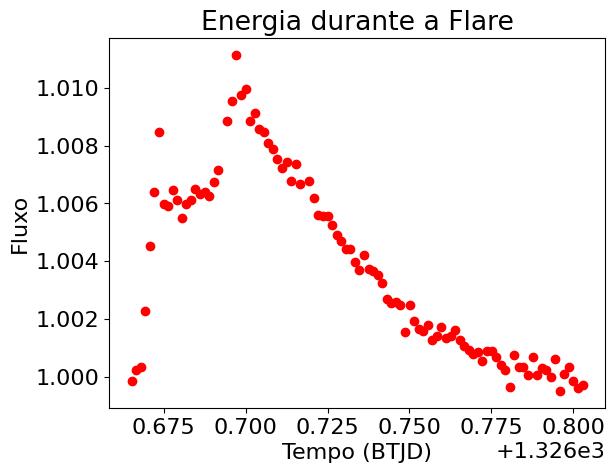

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Valores de início e término da flare (substitua pelos valores desejados)
start_input = 1326.6645
stop_input = 1326.8041

def ener_flare(start, stop, time, flux):
    flux_flare = []
    tempo_flare = []
    for i in range(len(time)):
        if time[i] >= start and time[i] <= stop:
            flux_flare.append(flux[i])
            tempo_flare.append(time[i])

    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    
    return flux_flare, tempo_flare

# Chamada da função ener_flare com os dados de exemplo
flux_flare, tempo_flare = ener_flare(start_input, stop_input, time, flux)
#print(flux_flare)
#print(tempo_flare)
# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare, flux_flare, 'ro')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

7.168358969255106e+33


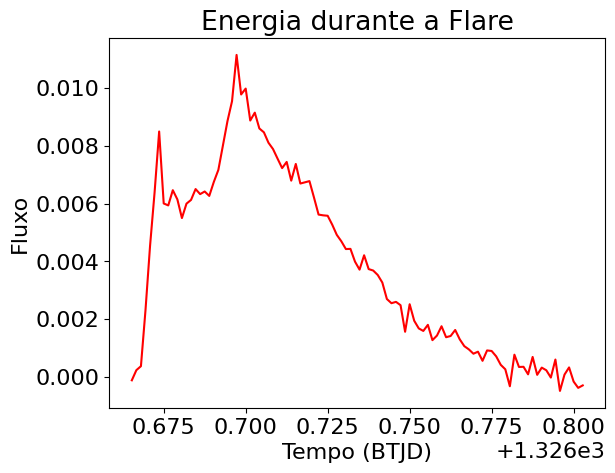

In [28]:
fluxo_flare1 = [0.9998779, 1.00023, 1.000367, 1.0023057, 1.0045295, 1.0063913,
                       1.0084965, 1.0060037, 1.0059358, 1.0064634, 1.0061435, 1.0054982,
                       1.0059965, 1.006126, 1.0065023, 1.0063267, 1.0064182, 1.0062648,
                       1.0067477, 1.0071669, 1.0088559, 1.0095445, 1.0111487, 1.0097787,
                       1.0099827, 1.008876, 1.0091492, 1.0086015, 1.0084672, 1.0081075,
                       1.007888, 1.0075557, 1.0072286, 1.007442, 1.0067936, 1.0073723,
                       1.0066938, 1.0067778, 1.0062066, 1.0056187, 1.0055922, 1.0055774,
                       1.0052688, 1.0049164, 1.0046933, 1.0044239, 1.0044309, 1.0039889,
                       1.0037111, 1.004209, 1.0037305, 1.0036799, 1.0035248, 1.003264,
                       1.0026937, 1.0025486, 1.0025952, 1.0024798, 1.0015599, 1.0025132,
                       1.001941, 1.0016752, 1.0015879, 1.0017991, 1.0012687, 1.0014278,
                       1.0017505, 1.0013705, 1.0014131, 1.0016212, 1.0012965, 1.0010608,
                       1.0009485, 1.0007991, 1.0008692, 1.0005529, 1.000913, 1.0008938,
                       1.0007074, 1.0004139, 1.0002594, 0.9996717, 1.0007654, 1.0003401,
                       1.000346, 1.0000848, 1.0006874, 1.0000678, 1.0003175, 1.0002261,
                       0.9999727, 1.0005975, 0.9995102, 1.0000765, 1.0003241, 0.9998342,
                       0.99961627, 0.9997013]

tempo_flare1 = [1326.6652889, 1326.66667779, 1326.66806668, 1326.66945556, 1326.67084445,
                       1326.67223334, 1326.67362222, 1326.67501111, 1326.67639999, 1326.67778888,
                       1326.67917776, 1326.68056665, 1326.68195554, 1326.68334442, 1326.68473331,
                       1326.6861222, 1326.68751108, 1326.68889997, 1326.69028885, 1326.69167774,
                       1326.69445551, 1326.6958444, 1326.69723328, 1326.69862217, 1326.70001105,
                       1326.70139994, 1326.70278883, 1326.70417771, 1326.7055666, 1326.70695548,
                       1326.70834437, 1326.70973326, 1326.71112214, 1326.71251103, 1326.71389991,
                       1326.7152888, 1326.71667769, 1326.71945546, 1326.72084434, 1326.72223323,
                       1326.72362212, 1326.725011, 1326.72639989, 1326.72778877, 1326.72917766,
                       1326.73056655, 1326.73195543, 1326.73334432, 1326.7347332, 1326.73612209,
                       1326.73751098, 1326.73889986, 1326.74028875, 1326.74167763, 1326.74306652,
                       1326.74445541, 1326.74584429, 1326.74723318, 1326.74862206, 1326.75001095,
                       1326.75139984, 1326.75278872, 1326.75417761, 1326.75556649, 1326.75695538,
                       1326.75834426, 1326.75973315, 1326.76112204, 1326.76251092, 1326.76389981,
                       1326.76528869, 1326.76667758, 1326.76806647, 1326.76945535, 1326.77084424,
                       1326.77223312, 1326.77362201, 1326.7750109, 1326.77639978, 1326.77778867,
                       1326.77917755, 1326.78056644, 1326.78195533, 1326.78334421, 1326.7847331,
                       1326.78612198, 1326.78751087, 1326.78889975, 1326.79028864, 1326.79167753,
                       1326.79306641, 1326.7944553, 1326.79584418, 1326.79723307, 1326.79862196,
                       1326.80001084, 1326.80139973, 1326.80278861]

flux_flare1 = np.array(fluxo_flare1)
tempo_flare1 = np.array(tempo_flare1) 

# Fluxo relativo da estrela (valor mínimo de fluxo na região da flare)
f_rel_estrela = np.min(flux_flare1)

# Calcular a amplitude da flare (diferença entre o fluxo máximo da flare e o fluxo relativo da estrela)
amplitude_flare =  flux_flare1 - 1


# Integral
Aflare = amplitude_flare*np.pi*(raio**2) #(cm^2)

Aflare1 = simps(ry*Bs,nm_cm)/simps(ry*Bf,nm_cm)

# Área total da flare
Atotal = Aflare*Aflare1 #cm^2

# Luminosidade da flare
L = sb1*(Tflare**4)*Atotal #erg/s

# Energia bolométrica do flare

E1 = simps(L,tempo_flare1*86400) #erg



print(E1)

# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare1, amplitude_flare, 'r-')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

In [29]:
flux_flarex1 = np.array(fluxo_flare)
tempo_flarex1 = np.array(tempo_flare) 

# Fluxo relativo da estrela (valor mínimo de fluxo na região da flare)
f_rel_estrela = np.min(flux_flarex1)

# Calcular a amplitude da flare (diferença entre o fluxo máximo da flare e o fluxo relativo da estrela)
amplitude_flare2 =  flux_flarex1 - 1


# Integral
Aflare = amplitude_flare2*np.pi*(raio**2) #(cm^2)

Aflare1 = simps(ry*Bs,nm_cm)/simps(ry*Bf,nm_cm)

# Área total da flare
Atotal = Aflare*Aflare1 #cm^2

# Luminosidade da flare
L = sb1*(Tflare**4)*Atotal #erg/s

# Energia bolométrica do flare

E1 = simps(L,tempo_flarex1*86400) #erg



print(E1)

# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flarex1, amplitude_flare2, 'r-')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

NameError: name 'fluxo_flare' is not defined